# Convolutional Neural Networks in PyTorch

The third notebook in the series, following:

1. [`basic_neural_net.ipynb`](basic_neural_net.ipynb) — a two-layer network in
   pure NumPy, every gradient derived by hand.
2. [`basic_neural_net_pytorch.ipynb`](basic_neural_net_pytorch.ipynb) — the
   *same* network in PyTorch, so that the framework was the only thing that
   changed.

**Here the framework stays fixed and the architecture changes.** We keep
PyTorch and swap the fully connected hidden layer for **convolutions**, which
exploit the fact that our inputs are images rather than arbitrary vectors of
784 numbers.

Taking one step at a time is the point. Notebook 2 isolated what PyTorch does
for you; this one isolates what convolution does for you. Any improvement here
is attributable to the architecture, because nothing else moved.

## What is assumed, and what is new

Notebook 2 already covered `nn.Module`, autograd, `nn.CrossEntropyLoss` and
`optimizer.step()`, so those are used here without re-deriving them. What this
notebook adds:

| New in this notebook | Why it is needed |
|---|---|
| Images as 4-D `(N, C, H, W)` tensors | convolution needs the grid back |
| `nn.Conv2d`, `F.max_pool2d` | the architecture itself |
| Output-size arithmetic, padding and stride | to know what shape comes out |
| `DataLoader` mini-batches | notebook 2 stayed full-batch deliberately |



## Roadmap

| Section | Topic |
|---|---|
| 1–2 | Setup, device selection, and the data as 4-D tensors |
| 3 | Why convolution: local receptive fields, weight sharing, equivariance |
| 4 | Output-size arithmetic and pooling |
| 5 | The architecture, layer by layer |
| 6 | Autograd: what `loss.backward()` actually does |
| 7 | Loss and optimizer |
| 8 | Mini-batch training |
| 9–10 | Evaluation and inspection of learned filters |
| 11 | Comparison across all three notebooks |

---
## 1. Setup

Beyond the usual scientific stack we import `torch`, its neural-network module
`torch.nn`, and the data utilities.

PyTorch runs on whichever accelerator is available. We select it once, here,
and move both the model and every batch of data onto it. A common beginner
error is leaving one of the two on the CPU, which raises a device-mismatch
error at the first matrix product.

* `cuda` — an NVIDIA GPU
* `mps` — Apple silicon (Metal Performance Shaders)
* `cpu` — always available, and perfectly adequate for a network this small

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from matplotlib import pyplot as plt

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PyTorch {torch.__version__}")
print(f"device: {device}")

PyTorch 2.7.1
device: mps


---
## 2. The data, as 4-D tensors

We read the same `train.csv` as before — 42,000 rows, each a label followed by
784 pixel values — and use the same 80/20 split, so the accuracies at the end
are directly comparable.

### 2.1 The shape changes

This is the substantive difference from the previous notebook, and it is worth
dwelling on. There, a batch was a flat matrix of rows:

$$
X \in \mathbb{R}^{m \times 784}
\qquad\text{(one example per row, pixels flattened across)}
$$

(The NumPy notebook used the transpose of that, $784 \times m$, with examples
as columns. Notebook 2 switched to rows because that is what every PyTorch
layer expects.)

Flattening throws away geometry. Pixel 100 and pixel 128 sit directly above and
below one another in the image, but after flattening they are simply entries
100 and 128 of a vector, no more related than any other pair. A fully connected
layer cannot recover that adjacency; it has to *learn* it from data.

A convolution needs the geometry back, so PyTorch keeps images in **NCHW**
order:

$$
X \in \mathbb{R}^{N \times C \times H \times W}
= \mathbb{R}^{m \times 1 \times 28 \times 28}
$$

| Axis | Meaning | Here |
|---|---|---|
| $N$ | examples in the batch | 64 |
| $C$ | channels | 1 (grayscale; a colour image would be 3) |
| $H$ | height | 28 |
| $W$ | width | 28 |

Examples remain the first axis, as in notebook 2. What is new is that the 784
flat pixels regain their structure as $1 \times 28 \times 28$ — a single
channel of a 28-by-28 grid.

### 2.2 Labels

The labels stay as integers $0..9$. We do **not** one-hot encode them:
`nn.CrossEntropyLoss` takes integer class indices directly and does the
equivalent internally, which makes the `one_hot` function from the previous
notebook unnecessary.

### 2.3 `Dataset` and `DataLoader`

Rather than one enormous batch, we now train on mini-batches of 64. A
`TensorDataset` pairs inputs with labels, and a `DataLoader` handles shuffling
and slicing them into batches each epoch. Section 8 explains why mini-batches
are worth the extra machinery.

In [2]:
from pathlib import Path

# Where train.csv might live, checked in order.
CANDIDATE_PATHS = [
    Path("data/train.csv.gz"),                                  # ships with this repository
    Path("data/train.csv"),                                     # uncompressed, if you have it
    Path("train.csv.gz"),                                       # same folder
    Path("train.csv"),                                          # same folder
    Path("/content/drive/MyDrive/digit-recognizer/train.csv"),  # Drive, inside Colab
]

# Google Drive for Desktop syncs Drive into a local folder whose exact name
# depends on the account, so we glob for it rather than hard-coding one.
DRIVE_PATTERNS = [
    "My Drive*/digit-recognizer/train.csv",
    "Google Drive*/digit-recognizer/train.csv",
    "Library/CloudStorage/GoogleDrive*/My Drive/digit-recognizer/train.csv",
]


def locate_training_csv():
    """Find train.csv locally, in a synced Google Drive, or by mounting Drive in Colab."""
    for path in CANDIDATE_PATHS:
        if path.exists():
            return path

    # Google Drive for Desktop, already synced onto this machine.
    for pattern in DRIVE_PATTERNS:
        for path in sorted(Path.home().glob(pattern)):
            return path

    # Running inside Colab: mount Drive, then look again.
    try:
        from google.colab import drive
    except ImportError:
        pass
    else:
        drive.mount("/content/drive")
        for path in CANDIDATE_PATHS:
            if path.exists():
                return path

    raise FileNotFoundError(
        "Could not find the training data. It ships with this repository at "
        "data/train.csv.gz, so if it is missing, re-clone from "
        "https://github.com/RibeiroResearch/neural-nets-tutorials or place a "
        "copy at one of: " + ", ".join(str(p) for p in CANDIDATE_PATHS)
    )


data = np.array(pd.read_csv(locate_training_csv()))

# Same shuffle and same 80/20 split as both previous notebooks.
rng = np.random.default_rng(SEED)
rng.shuffle(data)
n_train = int(0.8 * data.shape[0])

def to_tensors(rows):
    """Split a (n, 785) array into an NCHW image tensor and a label tensor."""
    images = rows[:, 1:].reshape(-1, 1, 28, 28) / 255.0
    labels = rows[:, 0]
    return (torch.tensor(images, dtype=torch.float32),
            torch.tensor(labels, dtype=torch.long))


X_train, Y_train = to_tensors(data[:n_train])
X_val, Y_val = to_tensors(data[n_train:])

BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train, Y_train),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, Y_val), batch_size=512)

print(f"X_train: {tuple(X_train.shape)}   Y_train: {tuple(Y_train.shape)}")
print(f"X_val:   {tuple(X_val.shape)}    Y_val:   {tuple(Y_val.shape)}")
print(f"pixel range: [{X_train.min():.1f}, {X_train.max():.1f}]")
print(f"batches per epoch: {len(train_loader)}")

X_train: (33600, 1, 28, 28)   Y_train: (33600,)
X_val:   (8400, 1, 28, 28)    Y_val:   (8400,)
pixel range: [0.0, 1.0]
batches per epoch: 525


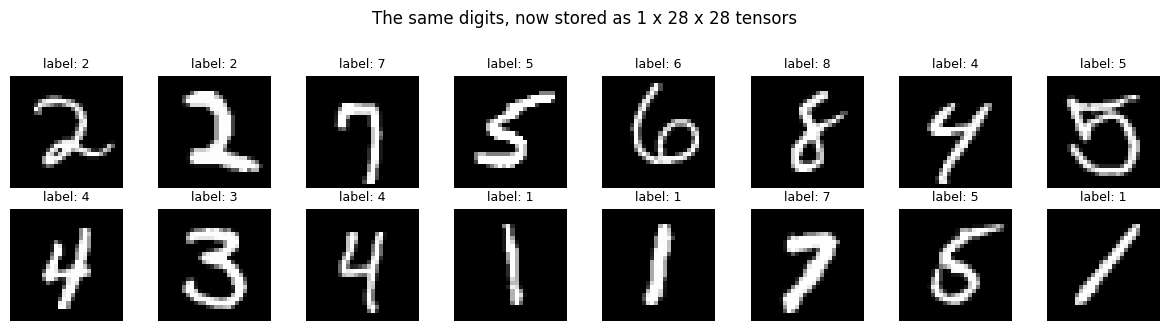

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for k, ax in enumerate(axes.flat):
    ax.imshow(X_train[k, 0], cmap="gray")   # [k, 0] = example k, channel 0
    ax.set_title(f"label: {Y_train[k].item()}", fontsize=9)
    ax.axis("off")
fig.suptitle("The same digits, now stored as 1 x 28 x 28 tensors", y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Why convolution?

### 3.1 The problem with fully connected layers on images

In both previous notebooks, every hidden unit was connected to all 784 pixels:
$z_j = w_j^\top x + b_j$, with $w_j \in \mathbb{R}^{784}$. Two consequences
follow, and both are bad for images.

**It is enormous.** A hidden layer preserving the image resolution would need
$784 \times 784 \approx 614{,}000$ weights for a single layer.

**It does not generalize across position.** A unit that learns to detect a
vertical stroke in the top-left corner has learned nothing about vertical
strokes in the bottom-right; those involve entirely different weights, which
must be learned separately from separate examples. Yet a vertical stroke is the
same feature wherever it appears. The fully connected layer has no way to know
that.

### 3.2 The convolution

A convolutional layer replaces the global inner product with a small kernel
$K \in \mathbb{R}^{k_H \times k_W}$ slid across the image. For a single input
and output channel, the output at position $(i, j)$ is

$$
S(i, j) \;=\; \sum_{u=0}^{k_H - 1} \sum_{v=0}^{k_W - 1}
K(u, v) \cdot I(i + u,\; j + v) \;+\; b .
$$

Every output pixel is an inner product between the kernel and a small patch of
the input — the same operation as before, but applied *locally* and with *the
same weights* at every position.

> Strictly, this is **cross-correlation**; true convolution flips the kernel,
> $K(u,v) \to K(k_H - 1 - u,\, k_W - 1 - v)$. Since $K$ is learned, the flip is
> irrelevant — the network simply learns the flipped kernel — and every deep
> learning framework, PyTorch included, implements cross-correlation and calls
> it convolution.

With multiple channels the kernel gains a channel axis and we sum over it. For
$C_{\text{in}}$ input channels and output channel $c$:

$$
S_c(i, j) \;=\; \sum_{d=0}^{C_{\text{in}}-1} \sum_{u} \sum_{v}
K_c(d, u, v) \cdot I_d(i + u,\; j + v) \;+\; b_c .
$$

So a layer's weight tensor has shape
$C_{\text{out}} \times C_{\text{in}} \times k_H \times k_W$, and its parameter
count is $C_{\text{out}} \cdot C_{\text{in}} \cdot k_H \cdot k_W + C_{\text{out}}$
— **independent of the image size**.

### 3.3 The three properties that follow

**Local receptive fields.** Each output depends on a $k_H \times k_W$ patch,
not the whole image. This encodes the assumption that nearby pixels are more
related than distant ones — true of images, false of arbitrary feature vectors.

**Weight sharing.** The same kernel is applied everywhere, so a feature learned
at one location is available at all of them. This is what collapses 614,000
weights into 9, and it means every training image teaches the kernel about that
feature, regardless of where in the frame it appeared.

**Translation equivariance.** Shifting the input shifts the output by the same
amount: if $I'(i,j) = I(i - \Delta_i,\, j - \Delta_j)$, then
$S'(i,j) = S(i - \Delta_i,\, j - \Delta_j)$. A shifted digit produces shifted
features rather than unrelated ones.

The parameter comparison for one $3 \times 3$ kernel on a $28 \times 28$ image:

| | Weights |
|---|---|
| Fully connected, $784 \to 784$ | 614,656 |
| One $3\times3$ convolution kernel | 9 |

Let us watch a hand-built kernel act on a real digit, before any training.

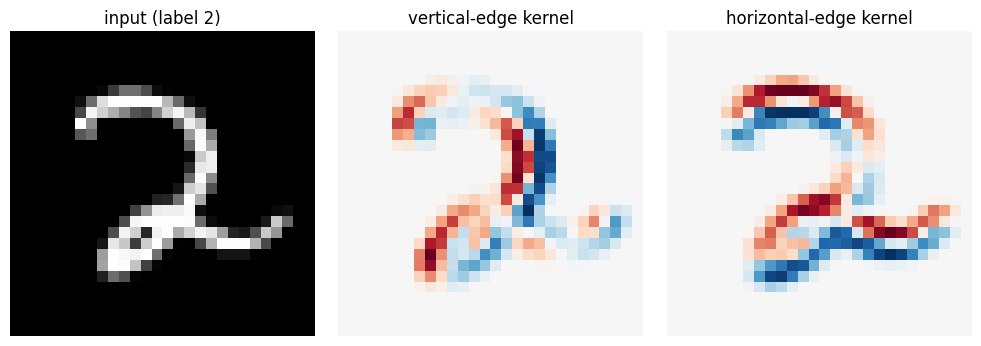

one 3x3 kernel: 9 weights
equivalent fully connected 784->784 layer: 614,656 weights


In [4]:
# Two classic edge detectors, applied to one digit with F.conv2d.
vertical_edges = torch.tensor([[-1.0, 0.0, 1.0],
                               [-2.0, 0.0, 2.0],
                               [-1.0, 0.0, 1.0]])
horizontal_edges = vertical_edges.T

sample = X_train[0:1]                                  # (1, 1, 28, 28)
kernels = torch.stack([vertical_edges, horizontal_edges]).unsqueeze(1)  # (2,1,3,3)
responses = F.conv2d(sample, kernels, padding=1)       # (1, 2, 28, 28)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.4))
axes[0].imshow(sample[0, 0], cmap="gray")
axes[0].set_title(f"input (label {Y_train[0].item()})")
axes[1].imshow(responses[0, 0], cmap="RdBu_r")
axes[1].set_title("vertical-edge kernel")
axes[2].imshow(responses[0, 1], cmap="RdBu_r")
axes[2].set_title("horizontal-edge kernel")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print(f"one 3x3 kernel: {vertical_edges.numel()} weights")
print(f"equivalent fully connected 784->784 layer: {784 * 784:,} weights")

Each kernel responds to a different structure in the same image — one lights up
on vertical strokes, the other on horizontal ones — using nine numbers each.
The only difference in a trained network is that those nine numbers are
discovered by gradient descent rather than written down by hand.

---
## 4. Output sizes and pooling

### 4.1 Output-size arithmetic

Sliding a $k \times k$ kernel over an $H \times W$ input shrinks it: there are
fewer valid positions than pixels. With **padding** $p$ (rows and columns of
zeros added around the border) and **stride** $s$ (the step between successive
kernel positions), the output height is

$$
H_{\text{out}} \;=\; \left\lfloor \frac{H + 2p - k}{s} \right\rfloor + 1
$$

and identically for the width. Two cases cover most architectures:

* $k=3,\; p=1,\; s=1 \;\Rightarrow\; H_{\text{out}} = H$. **"Same" convolution** —
  the resolution is preserved, which is why $3\times3$ kernels with padding 1
  are ubiquitous.
* $k=3,\; p=0,\; s=1 \;\Rightarrow\; H_{\text{out}} = H - 2$. Each layer nibbles
  a pixel off each edge.

Getting this arithmetic wrong is the most common source of shape errors when
building a CNN, so it is worth being able to compute it by hand.

### 4.2 Pooling

**Max pooling** partitions its input into non-overlapping windows and keeps the
largest value in each:

$$
P(i, j) \;=\; \max_{0 \le u,v < k} S(i \cdot s + u,\; j \cdot s + v)
$$

With $k = s = 2$, this halves both spatial dimensions and discards three
quarters of the activations. It serves two purposes: it reduces the amount of
computation in later layers, and it grants a little **translation invariance** —
if the strongest response moves by one pixel within a window, the pooled output
is unchanged.

Pooling has no parameters. It contributes nothing to the parameter count and
nothing to learn; its backward pass simply routes each gradient to whichever
input was the maximum.

28x28 input:
  3x3, pad 1, stride 1 -> 28   ('same')
  3x3, pad 0, stride 1 -> 26
  5x5, pad 0, stride 1 -> 24
  2x2 max pool (k=s=2) -> 14


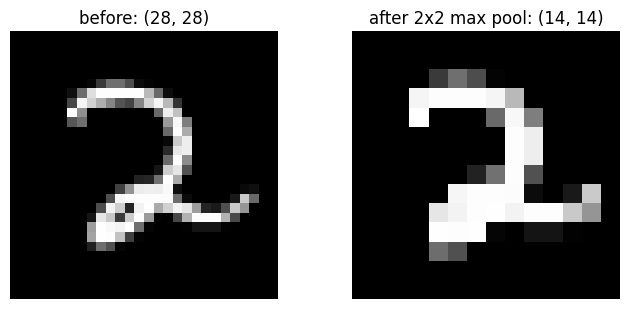

In [5]:
def conv_output_size(size, kernel, padding=0, stride=1):
    """floor((size + 2p - k) / s) + 1"""
    return (size + 2 * padding - kernel) // stride + 1


print("28x28 input:")
print(f"  3x3, pad 1, stride 1 -> {conv_output_size(28, 3, padding=1)}   ('same')")
print(f"  3x3, pad 0, stride 1 -> {conv_output_size(28, 3)}")
print(f"  5x5, pad 0, stride 1 -> {conv_output_size(28, 5)}")
print(f"  2x2 max pool (k=s=2) -> {conv_output_size(28, 2, stride=2)}")

# Max pooling in action.
pooled = F.max_pool2d(sample, kernel_size=2)
fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(7, 3.2))
ax_a.imshow(sample[0, 0], cmap="gray")
ax_a.set_title(f"before: {tuple(sample.shape[2:])}")
ax_b.imshow(pooled[0, 0], cmap="gray")
ax_b.set_title(f"after 2x2 max pool: {tuple(pooled.shape[2:])}")
for ax in (ax_a, ax_b):
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## 5. The architecture

We stack two convolution blocks and finish with a single linear layer. Each
block is the standard *convolve, activate, pool* triple:

| Stage | Operation | Output shape $(C, H, W)$ | Parameters |
|---|---|---|---|
| input | — | $1 \times 28 \times 28$ | 0 |
| conv1 | $3\times3$, 1→8, pad 1 | $8 \times 28 \times 28$ | $8\cdot1\cdot9 + 8 = 80$ |
| | ReLU | $8 \times 28 \times 28$ | 0 |
| pool1 | $2\times2$ max | $8 \times 14 \times 14$ | 0 |
| conv2 | $3\times3$, 8→16, pad 1 | $16 \times 14 \times 14$ | $16\cdot8\cdot9 + 16 = 1{,}168$ |
| | ReLU | $16 \times 14 \times 14$ | 0 |
| pool2 | $2\times2$ max | $16 \times 7 \times 7$ | 0 |
| flatten | — | $784$ | 0 |
| fc | linear 784→10 | $10$ | $784\cdot10 + 10 = 7{,}850$ |

**Total: 9,098 parameters** — within striking distance of the from-scratch
network's 7,960, which makes the comparison at the end a fair one.

Two things are worth noticing in that table.

First, the spatial dimensions shrink while the channel count grows: $28\to14\to7$
against $1\to8\to16$. This is the standard CNN shape, and it reflects a
progression from *where* to *what* — early layers hold precise positions of
simple features, later layers hold the presence of more complex ones at coarser
resolution.

Second, after two pooling stages the tensor is $16 \times 7 \times 7 = 784$
values — exactly the input dimension of the original notebook. The final linear
layer is therefore the *same shape* as the one we wrote by hand. The difference
is that it now sees 784 learned features rather than 784 raw pixels, and that
difference is worth about eight points of accuracy.

### Defining a model in PyTorch

A model subclasses `nn.Module` and implements two methods:

* `__init__` — construct and register the layers that own parameters. Assigning
  a layer to `self` registers its parameters automatically, which is how
  `model.parameters()` later finds them for the optimizer.
* `forward` — the computation. This corresponds exactly to
  `forward_propagation` in the NumPy notebook.

There is no `backward` to write. That is the whole point of autograd, and
Section 6 explains how it manages without one.

In [6]:
class DigitCNN(nn.Module):
    """Two convolution blocks followed by a single linear classifier."""

    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8,
                               kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16,
                               kernel_size=3, padding=1)
        self.fc = nn.Linear(16 * 7 * 7, num_classes)

    def forward(self, x):
        # x: (N, 1, 28, 28)
        x = F.relu(self.conv1(x))            # (N,  8, 28, 28)
        x = F.max_pool2d(x, 2)               # (N,  8, 14, 14)
        x = F.relu(self.conv2(x))            # (N, 16, 14, 14)
        x = F.max_pool2d(x, 2)               # (N, 16,  7,  7)
        x = torch.flatten(x, start_dim=1)    # (N, 784)  keep the batch axis
        return self.fc(x)                    # (N, 10)   raw logits


model = DigitCNN().to(device)
print(model)

DigitCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc): Linear(in_features=784, out_features=10, bias=True)
)


In [7]:
# Confirm the shapes and the parameter count from the table above.
with torch.no_grad():
    logits = model(X_train[:4].to(device))
print(f"input {tuple(X_train[:4].shape)} -> output {tuple(logits.shape)}\n")

total = 0
for name, parameter in model.named_parameters():
    print(f"{name:<14} {str(tuple(parameter.shape)):<18} {parameter.numel():>6,}")
    total += parameter.numel()
print(f"{'total':<14} {'':<18} {total:>6,}")
print(f"\nfrom-scratch network, for comparison:      7,960")

input (4, 1, 28, 28) -> output (4, 10)

conv1.weight   (8, 1, 3, 3)           72
conv1.bias     (8,)                    8
conv2.weight   (16, 8, 3, 3)       1,152
conv2.bias     (16,)                  16
fc.weight      (10, 784)           7,840
fc.bias        (10,)                  10
total                              9,098

from-scratch network, for comparison:      7,960


---
## 6. Autograd: what `loss.backward()` does

Notebook 2 introduced this in its Section 7, and checked autograd against the
six hand-derived equations. Nothing here is new — it is repeated briefly
because a convolutional network is where you stop being able to do the
derivation by hand, and it is worth seeing that the mechanism does not change.

Every tensor with `requires_grad=True` — which includes all model parameters —
carries a record of the operation that produced it. As the forward pass runs,
PyTorch builds a **directed acyclic graph** of these operations. Calling
`.backward()` on a scalar loss walks that graph in reverse, applying the chain
rule at each node, and accumulates the result in each parameter's `.grad`.

In other words, autograd performs mechanically the same computation we did by
hand:

$$
\frac{\partial \mathcal{L}}{\partial W^{[\ell]}}
= \frac{\partial \mathcal{L}}{\partial Z^{[\ell]}}
\frac{\partial Z^{[\ell]}}{\partial W^{[\ell]}}
$$

The rules are identical — our $dZ^{[2]} = A^{[2]} - Y$ is exactly what autograd
computes through `CrossEntropyLoss`. What has changed is who writes them down.
This is also why the gradient check of Section 12 is no longer needed: autograd
is not approximating anything, it is applying exact derivative rules to the
graph you built.

### Gradients accumulate

One behaviour surprises nearly everyone. `.backward()` **adds** to `.grad`
rather than overwriting it, so without intervention the gradients from every
batch would pile up. Hence `optimizer.zero_grad()` before each backward pass.

This is deliberate, not an oversight: accumulation is what lets you simulate a
large batch on a small GPU by summing gradients over several forward passes
before stepping. It just means the zeroing is your responsibility.

The demonstration below verifies both claims on a single parameter.

In [8]:
demo = DigitCNN().to(device)
images, labels = X_train[:64].to(device), Y_train[:64].to(device)
criterion = nn.CrossEntropyLoss()

print("grad before any backward pass:", demo.conv1.bias.grad)

loss = criterion(demo(images), labels)
loss.backward()
first = demo.conv1.bias.grad.clone()
print(f"after one backward:   {first[:3].tolist()}")

# A second backward pass without zeroing ADDS to the existing gradient.
loss = criterion(demo(images), labels)
loss.backward()
second = demo.conv1.bias.grad.clone()
print(f"after a second:       {second[:3].tolist()}")
print(f"exactly doubled:      {torch.allclose(second, 2 * first)}")

demo.zero_grad(set_to_none=False)
print(f"after zero_grad:      {demo.conv1.bias.grad[:3].tolist()}")

grad before any backward pass: None


after one backward:   [0.005722890142351389, 0.005162212066352367, -0.0036735229659825563]
after a second:       [0.011445780284702778, 0.010324424132704735, -0.007347045931965113]


exactly doubled:      True
after zero_grad:      [0.0, 0.0, 0.0]


---
## 7. Loss and optimizer

### 7.1 `nn.CrossEntropyLoss` expects logits

The loss is the same categorical cross-entropy we derived before,

$$
\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \log a^{(i)}_{k^{(i)}},
$$

but PyTorch's implementation folds the softmax inside. `nn.CrossEntropyLoss` is
`LogSoftmax` followed by `NLLLoss`, and it takes **raw logits** $z$ and
**integer labels**.

This catches people out, and the failure is silent: applying a softmax yourself
and passing the probabilities in produces a model that still trains, just
poorly, because the softmax gets applied twice. Our `forward` therefore returns
`self.fc(x)` with no activation on the end.

The reason for the fusion is numerical, and it is the same issue as the
max-shift in Section 5.3 of the NumPy notebook. Computing
$\log \sum_j e^{z_j}$ naively overflows for large $z_j$; the **log-sum-exp**
identity

$$
\log \sum_j e^{z_j} \;=\; c + \log \sum_j e^{z_j - c},
\qquad c = \max_j z_j
$$

makes it safe, and fusing the two operations lets PyTorch apply it internally.
Doing the softmax separately would throw that protection away.

### 7.2 From SGD to Adam

Both previous notebooks used plain gradient descent,
$\theta \leftarrow \theta - \alpha \, \nabla_\theta \mathcal{L}$, which is
available here as `optim.SGD`. We use **Adam** instead, which adapts a separate
step size per parameter from running averages of the gradient and its square:

$$
\begin{aligned}
m_t &= \beta_1 m_{t-1} + (1-\beta_1)\, g_t
&\quad&\text{(mean of recent gradients)} \\
v_t &= \beta_2 v_{t-1} + (1-\beta_2)\, g_t^2
&\quad&\text{(mean of recent squared gradients)} \\
\hat{m}_t &= \frac{m_t}{1-\beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t}
&\quad&\text{(bias correction)} \\
\theta_t &= \theta_{t-1} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
\end{aligned}
$$

The intuition: dividing by $\sqrt{\hat{v}_t}$ shrinks the step for parameters
with large or erratic gradients and enlarges it for those with small, steady
ones. The $\hat{m}_t$ term is momentum, carrying progress through flat regions.
The bias correction compensates for $m_0 = v_0 = 0$, which would otherwise make
the first few steps far too small.

In practice Adam converges in fewer epochs than SGD with little tuning, which
is why $\alpha = 10^{-3}$ works here with no search at all.

In [9]:
LEARNING_RATE = 1e-3
EPOCHS = 10

model = DigitCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(criterion)
print(optimizer)

CrossEntropyLoss()
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


---
## 8. Training

### 8.1 Mini-batches

Both previous notebooks computed the gradient over all 33,600 training images
before taking a single step — **batch gradient descent** — and notebook 2 kept
that deliberately, so that mini-batching would not be confused with the switch
to PyTorch. This is where it is introduced.

Here we take a step after every 64 images. Each gradient is a noisier estimate
of the true one, but we get 525 steps per pass over the data instead of one.
The trade is overwhelmingly favourable: ten epochs is 5,250 steps, and it beats
the NumPy notebook's thousand full-batch steps by seven points of accuracy
while touching each image only ten times.

An **epoch** is one complete pass over the training set. The noise is not purely
a cost, either — it helps the optimizer escape narrow local minima and is
generally thought to improve generalization.

### 8.2 The loop

Each batch is the same three steps as before, in the same order:

| Step | NumPy notebook | PyTorch |
|---|---|---|
| forward | `forward_propagation(...)` | `model(images)` |
| loss | `cross_entropy_loss(...)` | `criterion(logits, labels)` |
| backward | `backward_propagation(...)` | `loss.backward()` |
| update | `update_parameters(...)` | `optimizer.step()` |

with `optimizer.zero_grad()` in front, for the accumulation reason of Section 6.

Two calls have appeared that neither previous notebook needed:

* `model.train()` / `model.eval()` switch the mode of layers that behave
  differently during training and inference. Our model has no such layers, but
  add dropout or batch norm and forgetting these silently corrupts the results —
  so it is a habit worth forming early.
* `torch.no_grad()` disables graph construction during evaluation, saving memory
  and time when no gradients are needed.

In [10]:
@torch.no_grad()
def evaluate(model, loader):
    """Average loss and accuracy over a loader, without building a graph."""
    model.eval()
    total_loss, correct, count = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        total_loss += criterion(logits, labels).item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        count += labels.size(0)
    return total_loss / count, correct / count

In [11]:
history = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, correct, count = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()             # gradients accumulate; clear them
        logits = model(images)            # forward
        loss = criterion(logits, labels)  # loss
        loss.backward()                   # backward (autograd)
        optimizer.step()                  # update

        running_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        count += labels.size(0)

    train_loss, train_acc = running_loss / count, correct / count
    val_loss, val_acc = evaluate(model, val_loader)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"epoch {epoch}/{EPOCHS}   "
          f"train loss {train_loss:.4f}  acc {train_acc:.4f}   |   "
          f"val loss {val_loss:.4f}  acc {val_acc:.4f}")

epoch 1/10   train loss 0.5067  acc 0.8533   |   val loss 0.1963  acc 0.9445


epoch 2/10   train loss 0.1470  acc 0.9576   |   val loss 0.1257  acc 0.9627


epoch 3/10   train loss 0.0986  acc 0.9697   |   val loss 0.0978  acc 0.9700


epoch 4/10   train loss 0.0781  acc 0.9765   |   val loss 0.0863  acc 0.9745


epoch 5/10   train loss 0.0648  acc 0.9801   |   val loss 0.0800  acc 0.9755


epoch 6/10   train loss 0.0566  acc 0.9824   |   val loss 0.0752  acc 0.9777


epoch 7/10   train loss 0.0507  acc 0.9849   |   val loss 0.0798  acc 0.9783


epoch 8/10   train loss 0.0463  acc 0.9852   |   val loss 0.0781  acc 0.9773


epoch 9/10   train loss 0.0419  acc 0.9861   |   val loss 0.0676  acc 0.9812


epoch 10/10   train loss 0.0375  acc 0.9881   |   val loss 0.0676  acc 0.9811


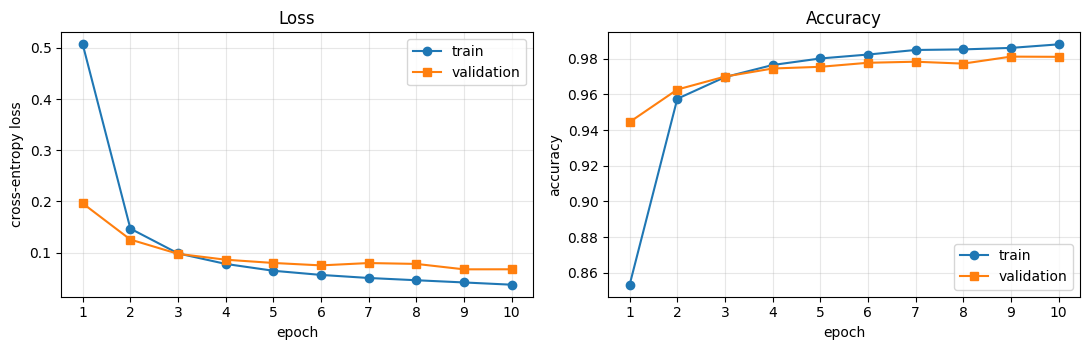

In [12]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(11, 3.6))

ax_loss.plot(history["epoch"], history["train_loss"], "o-", label="train")
ax_loss.plot(history["epoch"], history["val_loss"], "s-", label="validation")
ax_loss.set_xlabel("epoch"); ax_loss.set_ylabel("cross-entropy loss")
ax_loss.set_title("Loss"); ax_loss.legend(); ax_loss.grid(alpha=0.3)
ax_loss.set_xticks(history["epoch"])

ax_acc.plot(history["epoch"], history["train_acc"], "o-", label="train")
ax_acc.plot(history["epoch"], history["val_acc"], "s-", label="validation")
ax_acc.set_xlabel("epoch"); ax_acc.set_ylabel("accuracy")
ax_acc.set_title("Accuracy"); ax_acc.legend(); ax_acc.grid(alpha=0.3)
ax_acc.set_xticks(history["epoch"])

plt.tight_layout()
plt.show()

---
## 9. Evaluation

Tracking training and validation curves together is the standard way to watch
for overfitting: as long as both losses fall, the model is still learning
something general. When the training loss keeps dropping while the validation
loss turns upward, it has started memorizing.

In [13]:
@torch.no_grad()
def collect_predictions(model, X, batch_size=512):
    """Predicted labels for a whole tensor, evaluated in chunks."""
    model.eval()
    predictions = []
    for start in range(0, X.size(0), batch_size):
        logits = model(X[start:start + batch_size].to(device))
        predictions.append(logits.argmax(dim=1).cpu())
    return torch.cat(predictions)


val_predictions = collect_predictions(model, X_val)
val_accuracy = (val_predictions == Y_val).float().mean().item()

print(f"validation accuracy: {val_accuracy:.4f}")
print(f"errors: {(val_predictions != Y_val).sum().item()} of {Y_val.size(0)}")

validation accuracy: 0.9811
errors: 159 of 8400


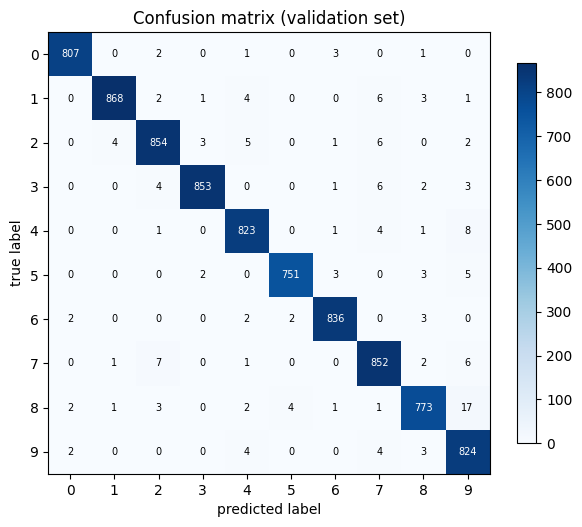

In [14]:
confusion = torch.zeros(10, 10, dtype=torch.long)
for true_label, predicted_label in zip(Y_val, val_predictions):
    confusion[true_label, predicted_label] += 1

fig, ax = plt.subplots(figsize=(6.2, 5.4))
image = ax.imshow(confusion, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("predicted label"); ax.set_ylabel("true label")
ax.set_title("Confusion matrix (validation set)")
for i in range(10):
    for j in range(10):
        ax.text(j, i, confusion[i, j].item(), ha="center", va="center", fontsize=7,
                color="white" if confusion[i, j] > confusion.max() / 2 else "black")
fig.colorbar(image, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

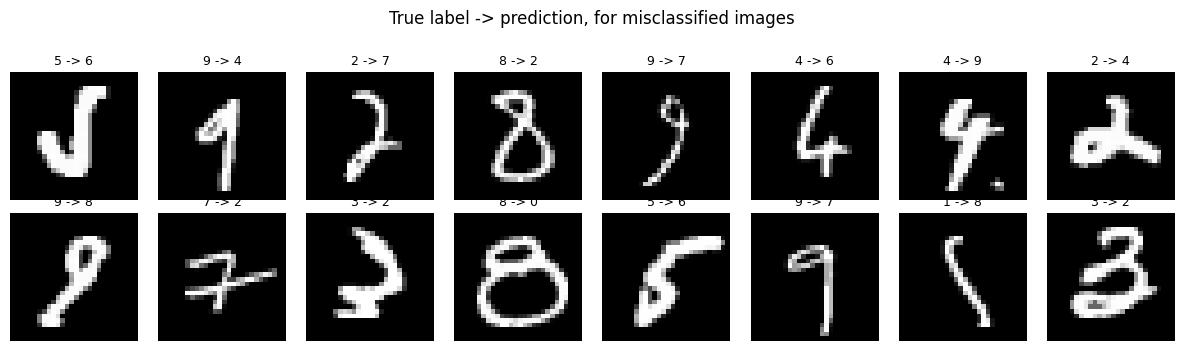

In [15]:
mistakes = torch.nonzero(val_predictions != Y_val).flatten()

fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for ax, idx in zip(axes.flat, mistakes[:16]):
    ax.imshow(X_val[idx, 0], cmap="gray")
    ax.set_title(f"{Y_val[idx].item()} -> {val_predictions[idx].item()}", fontsize=9)
    ax.axis("off")
for ax in axes.flat[len(mistakes[:16]):]:
    ax.axis("off")
fig.suptitle("True label -> prediction, for misclassified images", y=1.02)
plt.tight_layout()
plt.show()

---
## 10. What the convolutions learned

In both previous notebooks we reshaped rows of $W^{[1]}$ into $28 \times 28$
images and found the learned signal buried under the random initialization.
Convolutional filters are far easier to inspect: `conv1.weight` has shape
$8 \times 1 \times 3 \times 3$, so each filter is a $3\times3$ image, and their
**feature maps** — the eight $28\times28$ responses to a given input — show
directly what each one detects.

Below, the top row is the eight learned kernels; the bottom row is what each
produces when applied to a single digit. Compare them against the hand-built
edge detectors of Section 3: several filters have converged on something
similar, having been told only to reduce the loss.

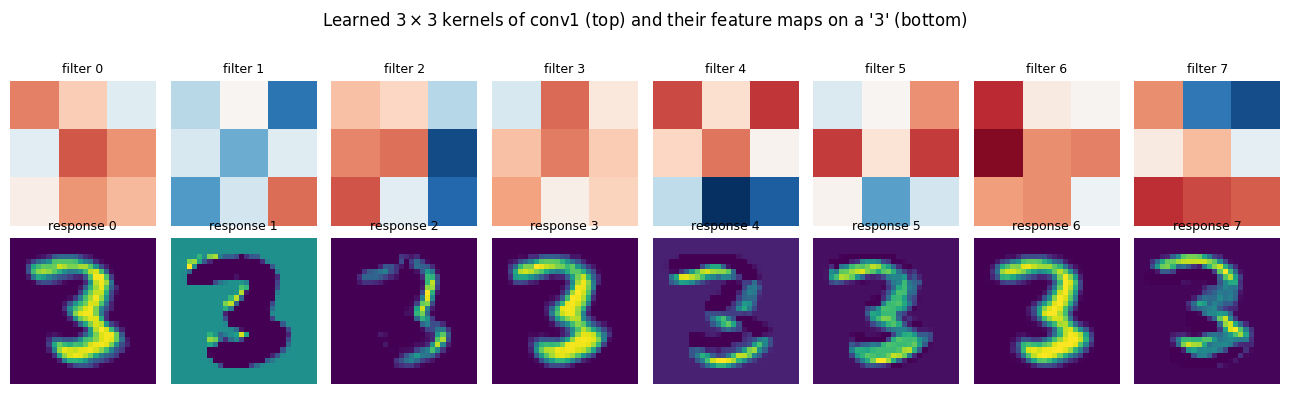

In [16]:
filters = model.conv1.weight.detach().cpu()          # (8, 1, 3, 3)
limit = filters.abs().max()

example = 0                                          # any validation image
one_digit = X_val[example:example + 1]               # keep the batch axis: (1,1,28,28)
with torch.no_grad():
    feature_maps = F.relu(model.conv1(one_digit.to(device))).cpu()[0]  # (8, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(13, 3.8))
for k in range(8):
    axes[0, k].imshow(filters[k, 0], cmap="RdBu_r", vmin=-limit, vmax=limit)
    axes[0, k].set_title(f"filter {k}", fontsize=9)
    axes[0, k].axis("off")

    axes[1, k].imshow(feature_maps[k], cmap="viridis")
    axes[1, k].set_title(f"response {k}", fontsize=9)
    axes[1, k].axis("off")

fig.suptitle(rf"Learned $3\times3$ kernels of conv1 (top) and their feature maps "
             rf"on a '{Y_val[example].item()}' (bottom)", y=1.03)
plt.tight_layout()
plt.show()

---
## 11. Comparison

### The two networks, side by side

| | Dense (NumPy) | Dense (PyTorch) | CNN (PyTorch) |
|---|---|---|---|
| Architecture | 784 → 10 → 10 | 784 → 10 → 10 | 2 conv blocks → 784 → 10 |
| Parameters | 7,960 | 7,960 | 9,098 |
| Optimizer | hand-written SGD, $\alpha=0.5$ | `optim.SGD`, $\alpha=0.5$ | Adam, $\alpha=10^{-3}$ |
| Updates | 1,000 (full-batch) | 1,000 (full-batch) | 5,250 (mini-batch, 10 epochs) |
| Passes over the data | 1,000 | 1,000 | 10 |
| Validation accuracy | 90.8% | 92.7% | 98.1% |
| Gradients | six equations, by hand | `loss.backward()` | `loss.backward()` |

Read across the row for validation accuracy and the series' argument is visible
in three numbers. Notebook 1 to notebook 2 changed only the framework, and the
small gain came from `nn.Linear`'s better initialization rather than from
PyTorch being faster or smarter. Notebook 2 to this one changed only the
architecture, and that is where the large gain is.

The parameter counts are nearly the same, so capacity is not what separates
them. What separates them is that the CNN's parameters are *arranged* to match
the structure of images — local, shared, and translation-equivariant — while the
dense layer had to learn the concept of adjacency from scratch, and largely
failed to. Architecture, not size, is doing the work.

It is worth being clear about what the framework did and did not contribute.
PyTorch removed the labour of differentiation and made the code shorter; it did
not make the model better. Had we implemented this same CNN in NumPy, with
convolution backprop derived by hand, it would score the same. The accuracy came
from convolution; the convenience came from PyTorch.
